# STAGE 09 — SIGNAL FREQUENCY CALIBRATION

Калибруем отдельные F/A/R для каждого коридора только на validation, стремясь к регулярным сигналам без потери predictive value. Ground truth неизменён: `GT_B = favourability_percentile_90 >= 0.85 AND actual_regret_5 <= 0.005`; actual regret используется только для evaluation. Forecasting-модели не переобучаются.

In [1]:
from pathlib import Path
import sys
import pandas as pd
from IPython.display import display
ROOT=Path.cwd().resolve()
if ROOT.name=='notebooks': ROOT=ROOT.parent
if str(ROOT) not in sys.path: sys.path.insert(0,str(ROOT))
from src.signal_frequency_calibration import plot_test, run_frequency_calibration
required=['reports/good_day_features_validation.csv','reports/good_day_features.csv','reports/per_corridor_rule_selection.csv']
inventory=pd.DataFrame({'artifact':required,'exists':[(ROOT/p).exists() for p in required]})
display(inventory)
if not inventory.exists.all(): raise FileNotFoundError(inventory.loc[~inventory.exists,'artifact'].tolist())
run=run_frequency_calibration(ROOT,make_plots=False)
print('Validation rows:',len(run['validation']),'Locked-test rows:',len(run['test']))
print('Forecasting retrained: NO')

,artifact,exists
0,reports/good_day_features_validation.csv,True
1,reports/good_day_features.csv,True
2,reports/per_corridor_rule_selection.csv,True


Validation rows: 1370 Locked-test rows: 1375
Forecasting retrained: NO


## 1. Validation-only calibration

Сетка содержит ровно 80 правил на коридор: F=[0.70,0.75,0.80,0.85,0.90], A=[None,-0.002,0,0.002], R=[0.003,0.005,0.0075,0.010]. Месяцы без сигналов включаются. Quality floor: uplift > 1 и hit rate > random hit rate.

In [2]:
print('Validation candidate rows:',len(run['candidates']))
display(run['selection'])

Validation candidate rows: 400


,corridor,selected_rule,F,A,R,status,reason,validation_n_signals,validation_median_signals_per_month,validation_share_months_with_2plus,validation_hit_rate,validation_uplift
0,AMD_RUB,F=0.900|A=-0.002|R=0.0100,0.90,-0.002,0.0100,FREQUENCY_TARGET_NOT_REACHED,No quality-preserving rule reached share_month...,55,2.5,0.571429,0.400000,2.756892
1,KGS_RUB,F=0.850|A=-0.002|R=0.0075,0.85,-0.002,0.0075,FREQUENCY_TARGET_NOT_REACHED,No quality-preserving rule reached share_month...,62,1.5,0.500000,0.370968,2.697420
2,KZT_RUB,F=0.750|A=0.002|R=0.0100,0.75,0.002,0.0100,FREQUENCY_TARGET_REACHED,Frequency target and quality floor passed on v...,45,3.5,0.785714,0.377778,2.194492
3,TJS_RUB,F=0.850|A=NONE|R=0.0100,0.85,NaN,0.0100,FREQUENCY_TARGET_NOT_REACHED,No quality-preserving rule reached share_month...,86,1.0,0.428571,0.395349,3.223767
4,UZS_RUB,F=0.900|A=-0.002|R=0.0030,0.90,-0.002,0.0030,FREQUENCY_TARGET_NOT_REACHED,No quality-preserving rule reached share_month...,56,3.5,0.642857,0.410714,2.538631


## 2. Locked test — raw rule и cooldown=3

Thresholds уже зафиксированы. Cooldown оставляет первый сигнал и подавляет следующие три quote observations; он показан отдельно и не влияет на threshold selection.

In [3]:
display(run['results'])

,corridor,policy,selected_rule,F,A,R,status,n_rows,n_signals,overall_signal_frequency,...,median_signals_per_month,min_signals_per_month,share_months_with_1plus,share_months_with_2plus,share_months_with_3plus,max_calendar_gap_days_between_signals,hit_rate,random_hit_rate,uplift,mean_actual_regret_signal
0,AMD_RUB,BEFORE_COOLDOWN,F=0.900|A=-0.002|R=0.0100,0.90,-0.002,0.0100,FREQUENCY_TARGET_NOT_REACHED,275,34,0.123636,...,1.0,0,0.571429,0.428571,0.357143,131.0,0.558824,0.140784,3.969359,0.009360
1,AMD_RUB,AFTER_COOLDOWN,F=0.900|A=-0.002|R=0.0100,0.90,-0.002,0.0100,FREQUENCY_TARGET_NOT_REACHED,275,14,0.050909,...,1.0,0,0.571429,0.357143,0.071429,136.0,0.571429,0.140714,4.060914,0.008652
2,KGS_RUB,BEFORE_COOLDOWN,F=0.850|A=-0.002|R=0.0075,0.85,-0.002,0.0075,FREQUENCY_TARGET_NOT_REACHED,275,52,0.189091,...,2.5,0,0.571429,0.571429,0.500000,122.0,0.403846,0.148526,2.719033,0.010905
3,KGS_RUB,AFTER_COOLDOWN,F=0.850|A=-0.002|R=0.0075,0.85,-0.002,0.0075,FREQUENCY_TARGET_NOT_REACHED,275,19,0.069091,...,1.0,0,0.571429,0.428571,0.285714,122.0,0.473684,0.150702,3.143190,0.008654
4,KZT_RUB,BEFORE_COOLDOWN,F=0.750|A=0.002|R=0.0100,0.75,0.002,0.0100,FREQUENCY_TARGET_REACHED,275,20,0.072727,...,0.0,0,0.428571,0.357143,0.214286,116.0,0.550000,0.081167,6.776181,0.006596
5,KZT_RUB,AFTER_COOLDOWN,F=0.750|A=0.002|R=0.0100,0.75,0.002,0.0100,FREQUENCY_TARGET_REACHED,275,10,0.036364,...,0.0,0,0.428571,0.214286,0.071429,116.0,0.400000,0.082667,4.838710,0.008987
6,TJS_RUB,BEFORE_COOLDOWN,F=0.850|A=NONE|R=0.0100,0.85,NaN,0.0100,FREQUENCY_TARGET_NOT_REACHED,275,83,0.301818,...,1.5,0,0.571429,0.500000,0.428571,39.0,0.433735,0.129759,3.342618,0.009536
7,TJS_RUB,AFTER_COOLDOWN,F=0.850|A=NONE|R=0.0100,0.85,NaN,0.0100,FREQUENCY_TARGET_NOT_REACHED,275,22,0.080000,...,0.5,0,0.500000,0.357143,0.357143,44.0,0.409091,0.134394,3.043968,0.010160
8,UZS_RUB,BEFORE_COOLDOWN,F=0.900|A=-0.002|R=0.0030,0.90,-0.002,0.0030,FREQUENCY_TARGET_NOT_REACHED,275,27,0.098182,...,0.5,0,0.500000,0.428571,0.285714,142.0,0.481481,0.111481,4.318937,0.008920
9,UZS_RUB,AFTER_COOLDOWN,F=0.900|A=-0.002|R=0.0030,0.90,-0.002,0.0030,FREQUENCY_TARGET_NOT_REACHED,275,12,0.043636,...,0.5,0,0.500000,0.285714,0.071429,143.0,0.500000,0.121944,4.100228,0.008214


## 3. Monthly tables

Таблица явно показывает месяцы с 0/1/2/3+ сигналами для raw и cooldown policies.

In [4]:
for corridor in sorted(run['monthly'].corridor.unique()):
    print(corridor)
    display(run['monthly'].loc[run['monthly'].corridor.eq(corridor)])

AMD_RUB


,corridor,month,policy,n_signals,n_good_hits,hit_rate
0,AMD_RUB,2025-07,BEFORE_COOLDOWN,3,3,1.000000
1,AMD_RUB,2025-08,BEFORE_COOLDOWN,0,0,NaN
2,AMD_RUB,2025-09,BEFORE_COOLDOWN,0,0,NaN
3,AMD_RUB,2025-10,BEFORE_COOLDOWN,0,0,NaN
4,AMD_RUB,2025-11,BEFORE_COOLDOWN,5,0,0.000000
5,AMD_RUB,2025-12,BEFORE_COOLDOWN,7,3,0.428571
6,AMD_RUB,2026-01,BEFORE_COOLDOWN,5,5,1.000000
7,AMD_RUB,2026-02,BEFORE_COOLDOWN,1,1,1.000000
8,AMD_RUB,2026-03,BEFORE_COOLDOWN,0,0,NaN
9,AMD_RUB,2026-04,BEFORE_COOLDOWN,2,2,1.000000


KGS_RUB


,corridor,month,policy,n_signals,n_good_hits,hit_rate
28,KGS_RUB,2025-07,BEFORE_COOLDOWN,4,4,1.000000
29,KGS_RUB,2025-08,BEFORE_COOLDOWN,0,0,NaN
30,KGS_RUB,2025-09,BEFORE_COOLDOWN,0,0,NaN
31,KGS_RUB,2025-10,BEFORE_COOLDOWN,0,0,NaN
32,KGS_RUB,2025-11,BEFORE_COOLDOWN,6,0,0.000000
33,KGS_RUB,2025-12,BEFORE_COOLDOWN,9,3,0.333333
34,KGS_RUB,2026-01,BEFORE_COOLDOWN,9,5,0.555556
35,KGS_RUB,2026-02,BEFORE_COOLDOWN,3,1,0.333333
36,KGS_RUB,2026-03,BEFORE_COOLDOWN,0,0,NaN
37,KGS_RUB,2026-04,BEFORE_COOLDOWN,6,2,0.333333


KZT_RUB


,corridor,month,policy,n_signals,n_good_hits,hit_rate
56,KZT_RUB,2025-07,BEFORE_COOLDOWN,5,3,0.600000
57,KZT_RUB,2025-08,BEFORE_COOLDOWN,2,2,1.000000
58,KZT_RUB,2025-09,BEFORE_COOLDOWN,0,0,NaN
59,KZT_RUB,2025-10,BEFORE_COOLDOWN,5,3,0.600000
60,KZT_RUB,2025-11,BEFORE_COOLDOWN,0,0,NaN
61,KZT_RUB,2025-12,BEFORE_COOLDOWN,0,0,NaN
62,KZT_RUB,2026-01,BEFORE_COOLDOWN,1,1,1.000000
63,KZT_RUB,2026-02,BEFORE_COOLDOWN,0,0,NaN
64,KZT_RUB,2026-03,BEFORE_COOLDOWN,0,0,NaN
65,KZT_RUB,2026-04,BEFORE_COOLDOWN,0,0,NaN


TJS_RUB


,corridor,month,policy,n_signals,n_good_hits,hit_rate
84,TJS_RUB,2025-07,BEFORE_COOLDOWN,0,0,NaN
85,TJS_RUB,2025-08,BEFORE_COOLDOWN,0,0,NaN
86,TJS_RUB,2025-09,BEFORE_COOLDOWN,0,0,NaN
87,TJS_RUB,2025-10,BEFORE_COOLDOWN,0,0,NaN
88,TJS_RUB,2025-11,BEFORE_COOLDOWN,2,0,0.000000
89,TJS_RUB,2025-12,BEFORE_COOLDOWN,11,6,0.545455
90,TJS_RUB,2026-01,BEFORE_COOLDOWN,13,4,0.307692
91,TJS_RUB,2026-02,BEFORE_COOLDOWN,18,7,0.388889
92,TJS_RUB,2026-03,BEFORE_COOLDOWN,1,1,1.000000
93,TJS_RUB,2026-04,BEFORE_COOLDOWN,14,6,0.428571


UZS_RUB


,corridor,month,policy,n_signals,n_good_hits,hit_rate
112,UZS_RUB,2025-07,BEFORE_COOLDOWN,2,1,0.500000
113,UZS_RUB,2025-08,BEFORE_COOLDOWN,0,0,NaN
114,UZS_RUB,2025-09,BEFORE_COOLDOWN,0,0,NaN
115,UZS_RUB,2025-10,BEFORE_COOLDOWN,0,0,NaN
116,UZS_RUB,2025-11,BEFORE_COOLDOWN,0,0,NaN
117,UZS_RUB,2025-12,BEFORE_COOLDOWN,4,4,1.000000
118,UZS_RUB,2026-01,BEFORE_COOLDOWN,7,1,0.142857
119,UZS_RUB,2026-02,BEFORE_COOLDOWN,1,1,1.000000
120,UZS_RUB,2026-03,BEFORE_COOLDOWN,0,0,NaN
121,UZS_RUB,2026-04,BEFORE_COOLDOWN,3,2,0.666667


## 4. Test-period plots

Красные точки — raw frequency-calibrated signals. Cooldown не смешивается с основным графиком. Lower rate = better.

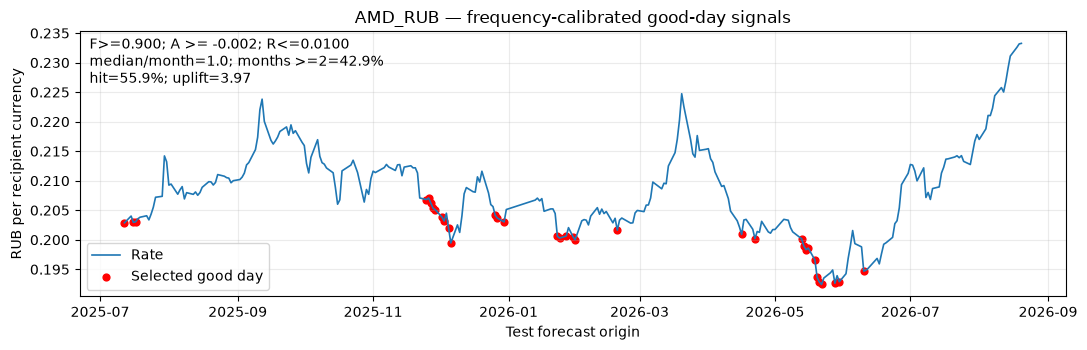

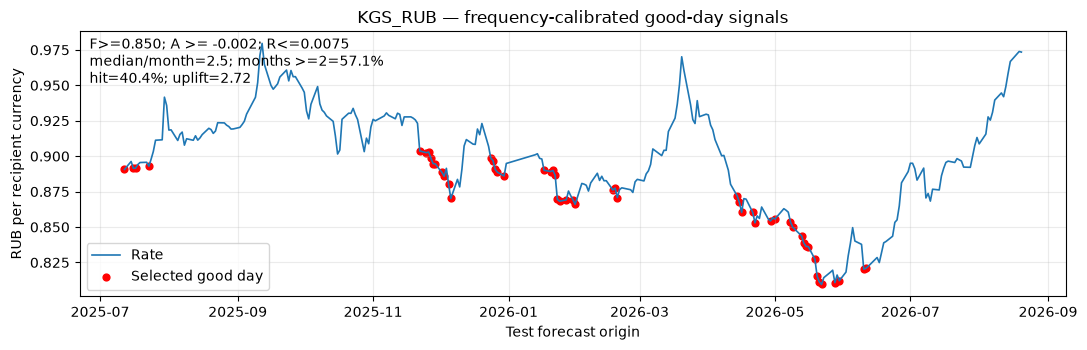

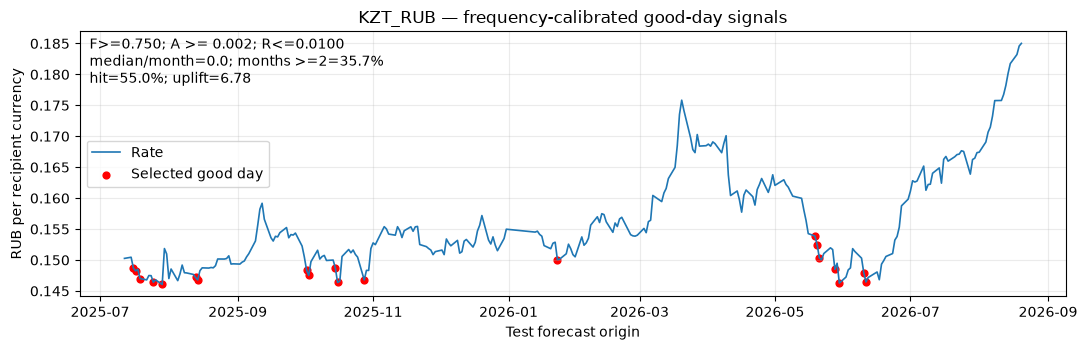

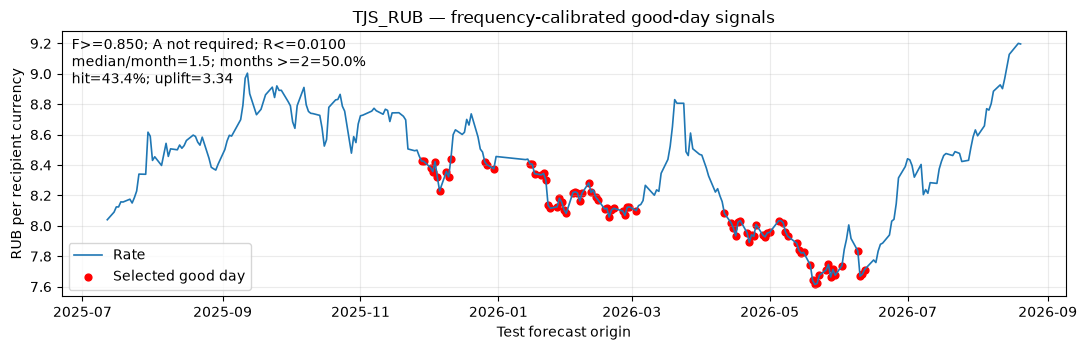

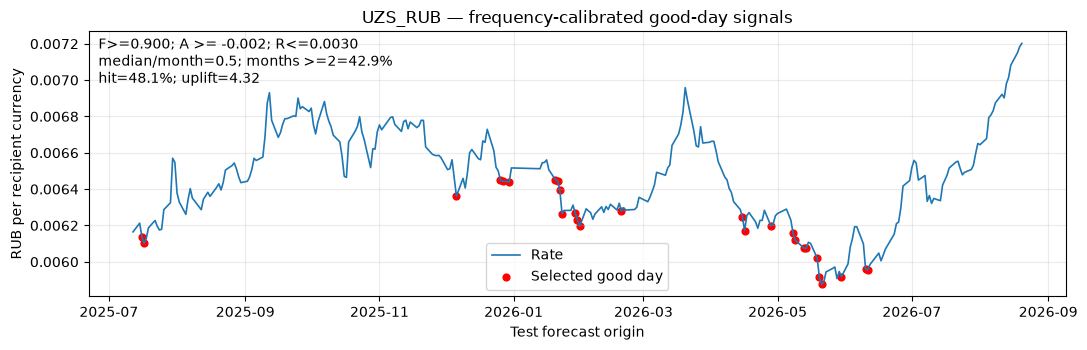

In [5]:
plot_test(run['predictions'],run['selection'],run['results'],ROOT/'reports/figures/frequency_calibration')

## 5. Trade-off относительно Stage 08

In [6]:
display(run['comparison'])

,corridor,stage08_test_uplift,new_test_uplift,stage08_test_hit_rate,new_test_hit_rate,stage08_total_signals,new_total_signals,stage08_median_signals_per_month,new_median_signals_per_month,stage08_share_months_with_2plus,new_share_months_with_2plus,stage08_max_gap_days,new_max_gap_days
0,AMD_RUB,3.670745,3.969359,0.500000,0.558824,22,34,0.5,1.0,0.357143,0.428571,136.0,131.0
1,KGS_RUB,2.201027,2.719033,0.322581,0.403846,31,52,0.5,2.5,0.428571,0.571429,54.0,122.0
2,KZT_RUB,6.617647,6.776181,0.600000,0.550000,10,20,0.0,0.0,0.214286,0.357143,280.0,116.0
3,TJS_RUB,3.277635,3.342618,0.419753,0.433735,81,83,1.5,1.5,0.500000,0.500000,39.0,39.0
4,UZS_RUB,3.889789,4.318937,0.421053,0.481481,19,27,0.5,0.5,0.357143,0.428571,161.0,142.0


## 6. Leakage check

In [7]:
display(run['leakage'])
leakage_status='PASS' if run['leakage'].passed.all() else 'FAIL'
print('FREQUENCY CALIBRATION LEAKAGE CHECK:',leakage_status)

,check,passed
0,threshold calibration validation only,True
1,test never used for selection,True
2,live rule uses only approved T-time fields,True
3,actual regret used only for evaluation,True
4,monthly constraints computed on validation,True
5,test evaluated only after thresholds locked,True


FREQUENCY CALIBRATION LEAKAGE CHECK: PASS


## 7. Final summary

In [8]:
raw=run['results'].loc[run['results'].policy.eq('BEFORE_COOLDOWN')]
final=run['selection'].merge(raw,on=['corridor','status'],suffixes=('_validation','_test'))
display(final[['corridor','F_validation','A_validation','R_validation','n_signals','median_signals_per_month','share_months_with_2plus','hit_rate','uplift','status']])
print(f"frequency target reached: {run['selection'].status.eq('FREQUENCY_TARGET_REACHED').sum()}/5 corridors")
print(f'test uplift > 1: {raw.uplift.gt(1).sum()}/5')
print(f'test uplift >= 1.3: {raw.uplift.ge(1.3).sum()}/5')
print('Leakage:',leakage_status)
for name,path in run['paths'].items(): print(f'{name}: {path.relative_to(ROOT)}')

,corridor,F_validation,A_validation,R_validation,n_signals,median_signals_per_month,share_months_with_2plus,hit_rate,uplift,status
0,AMD_RUB,0.90,-0.002,0.0100,34,1.0,0.428571,0.558824,3.969359,FREQUENCY_TARGET_NOT_REACHED
1,KGS_RUB,0.85,-0.002,0.0075,52,2.5,0.571429,0.403846,2.719033,FREQUENCY_TARGET_NOT_REACHED
2,KZT_RUB,0.75,0.002,0.0100,20,0.0,0.357143,0.550000,6.776181,FREQUENCY_TARGET_REACHED
3,TJS_RUB,0.85,NaN,0.0100,83,1.5,0.500000,0.433735,3.342618,FREQUENCY_TARGET_NOT_REACHED
4,UZS_RUB,0.90,-0.002,0.0030,27,0.5,0.428571,0.481481,4.318937,FREQUENCY_TARGET_NOT_REACHED


frequency target reached: 1/5 corridors
test uplift > 1: 5/5
test uplift >= 1.3: 5/5
Leakage: PASS
rules: reports\frequency_calibrated_rules.csv
results: reports\frequency_calibration_test_results.csv
monthly: reports\frequency_calibration_monthly.csv
predictions: reports\frequency_calibration_predictions.csv
report: reports\frequency_calibration_report.md
